# Reading NetCDF Files
The following cells will guide you through opening a NetCDF file, interpretting what is in the file, visualizing the data and finally being able to export the data as an array for other libraries to read.

## Python libraries
Here is the installation for the libaries needed to process the data. If any libraries fail loading in the `load libraries` cell, revist what needs to be installed in `install libraries` cell. The installation only needs to run once. The requirements.txt will have all of the necessary libraries, this step confirms `Requirement already satisfied`

In [1]:
# install libraries
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install netCDF4 xarray pandas matplotlib cartopy

In [2]:
# load libraries
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

C:\ProgramData\anaconda3\envs\noaa_ml\lib\site-packages\pyproj\__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# open netcdf file and view summary
"""
note:
if you see a warning foy `pyproj`, it is okay to ignore. Just a warning about setting a path on the local machine.
It has not impact on the ability to use the library
"""

nc_path = "SIVelocity_SAR_20241014_20241015_scenes_12km_NH_v00.nc" # assuming file in in notebook directory
ds = xr.open_dataset(nc_path, decode_times=False, mask_and_scale=False)
ds

<xarray.Dataset> Size: 2GB
Dimensions:                            (time: 127, y: 896, x: 608, nv: 2)
Coordinates:
  * nv                                 (nv) int64 16B 0 1
  * x                                  (x) float64 5kB -3.844e+06 ... 3.744e+06
  * y                                  (y) float64 7kB 5.844e+06 ... -5.344e+06
  * time                               (time) float64 1kB 7.822e+08 ... 7.823...
Data variables:
    sea_ice_speed                      (time, y, x) float32 277MB ...
    sea_ice_x_displacement             (time, y, x) float32 277MB ...
    sea_ice_y_displacement             (time, y, x) float32 277MB ...
    direction_of_sea_ice_displacement  (time, y, x) float32 277MB ...
    outlier_category                   (time, y, x) int16 138MB ...
    bearing_error                      (time, y, x) int16 138MB ...
    speed_error                        (time, y, x) int16 138MB ...
    measurement_error                  (time, y, x) int16 138MB ...
    spatial_ref                        int32 4B ...
    time_bnds                          (time, nv) float64 2kB ...
Attributes: (12/38)
    Conventions:               CF-1.8, ACDD-1.3
    title:                     Daily Northern Hemisphere SAR sea-ice velocity...
    summary:                   NetCDF version of the SAR Daily Drift dataset....
    acknowledgement:           Produced by NOAA using IABP data.
    creator_name:              Brendon Gory
    creator_email:             brendon.gory@noaa.gov
    ...                        ...
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    date_created:              2026-03-17T20:55:16Z
    time_coverage_start:       2024-10-14T01:02:01Z
    time_coverage_end:         2024-10-15T23:59:59Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D

In [4]:
# high-level structure of the netcdf like the above output

print("Dimensions:", dict(ds.sizes), "\n")
print("Coordinates:", list(ds.coords), "\n")
print("Data variables:", list(ds.data_vars), "\n")
print("Attributes:", list(ds.attrs))

Dimensions: {'time': 127, 'y': 896, 'x': 608, 'nv': 2} 

Coordinates: ['nv', 'x', 'y', 'time'] 

Data variables: ['sea_ice_speed', 'sea_ice_x_displacement', 'sea_ice_y_displacement', 'direction_of_sea_ice_displacement', 'outlier_category', 'bearing_error', 'speed_error', 'measurement_error', 'spatial_ref', 'time_bnds'] 

Attributes: ['Conventions', 'title', 'summary', 'acknowledgement', 'creator_name', 'creator_email', 'creator_institution', 'creator_type', 'creator_url', 'publisher_name', 'publisher_email', 'publisher_institution', 'publisher_type', 'publisher_url', 'contributor_name', 'contributor_role', 'processing_level', 'product_version', 'project', 'source', 'instrument', 'platform', 'platform_vocabulary', 'standard_name_vocabulary', 'keywords', 'keywords_vocabulary', 'license', 'history', 'references', 'metadata_link', 'sourceUrl', 'naming_authority', 'ncei_template_version', 'date_created', 'time_coverage_start', 'time_coverage_end', 'time_coverage_duration', 'time_coverage_re

In [5]:
# getting familiar with the scope of the data

# lon/lat ranges
x = np.round(ds['x'].values, 3)
y = np.round(ds['y'].values, 3)
print(f'x range (m): {x.min()} to {x.max()}')
print(f'y range (m): {y.min()} to {y.max()}\n')

# approximate grid resolution (assumes regular spacing, median is cleaner)
dx_grid = np.median(np.diff(x))
dy_grid = np.median(np.diff(y))
print(f'Approximate resolution: {dx_grid} m (x) x {dy_grid} m (y)\n')

# all time(s) in dataset
print(f'Time coordinate: {ds["time"].values}')

x range (m): -3843750.0 to 3743750.0
y range (m): -5343750.0 to 5843750.0

Approximate resolution: 12500.0 m (x) x -12500.0 m (y)

Time coordinate: [7.82182921e+08 7.82184835e+08 7.82185029e+08 7.82185029e+08
 7.82185029e+08 7.82185029e+08 7.82186736e+08 7.82186736e+08
 7.82186755e+08 7.82186789e+08 7.82188737e+08 7.82191068e+08
 7.82191068e+08 7.82191068e+08 7.82191068e+08 7.82194774e+08
 7.82194774e+08 7.82196377e+08 7.82196377e+08 7.82196377e+08
 7.82196456e+08 7.82196685e+08 7.82196685e+08 7.82198299e+08
 7.82198299e+08 7.82198299e+08 7.82198343e+08 7.82202516e+08
 7.82204438e+08 7.82206421e+08 7.82208325e+08 7.82208432e+08
 7.82209131e+08 7.82209194e+08 7.82210231e+08 7.82210231e+08
 7.82210231e+08 7.82210231e+08 7.82210266e+08 7.82212068e+08
 7.82212167e+08 7.82213973e+08 7.82215887e+08 7.82219733e+08
 7.82223585e+08 7.82223585e+08 7.82223643e+08 7.82223643e+08
 7.82223643e+08 7.82223760e+08 7.82227406e+08 7.82229367e+08
 7.82229367e+08 7.82229367e+08 7.82229400e+08 7.82229400e+0

In [6]:
# variable metadata
metadata = []
display_spatial_ref = False
for var in ds.data_vars:
    attrs = ds[var].attrs
    if 'spatial_ref' in var:
        # ignore spatial ref for each variable if it exists
        display_spatial_ref = True
        continue
    metadata.append(
        {
            'Variable': var,
            'Dims': ds[var].dims,
            'Dtype': ds[var].dtype,
            'Units': attrs.get('units', ''),
            'Standard Name': attrs.get('standard_name', ''),
            'Long Name': attrs.get('long_name', ''),
            'Grid Mapping': attrs.get('grid_mapping', '')
        }
    )

display(pd.DataFrame(metadata)) # display in nice data frame

,Variable,Dims,Dtype,Units,Standard Name,Long Name,Grid Mapping
0,sea_ice_speed,"(time, y, x)",float32,m s-1,sea_ice_speed,Sea ice speed,spatial_ref
1,sea_ice_x_displacement,"(time, y, x)",float32,m s-1,movement_in_x_direction,u-velocity component,spatial_ref
2,sea_ice_y_displacement,"(time, y, x)",float32,m s -1,movement_in_y_direction,v-velocity component,spatial_ref
3,direction_of_sea_ice_displacement,"(time, y, x)",float32,degrees,direction_of_sea_ice_displacement,Direction of the vector change in geospatial p...,spatial_ref
4,outlier_category,"(time, y, x)",int16,1,status_flag,Outlier category code,spatial_ref
5,bearing_error,"(time, y, x)",int16,1,status_flag,Possible bearing error flag,spatial_ref
6,speed_error,"(time, y, x)",int16,1,status_flag,Possible speed error flag,spatial_ref
7,measurement_error,"(time, y, x)",int16,1,status_flag,Possible measurement error flag,spatial_ref
8,time_bnds,"(time, nv)",float64,,,,


In [7]:
# display crs
if display_spatial_ref:
    display(pd.DataFrame(ds["spatial_ref"].attrs.items(), columns=["CRS attribute", "value"]))
    
for key, val in ds["spatial_ref"].attrs.items():
    print(f'{key}: {val}')

,CRS attribute,value
0,grid_mapping_name,polar_stereographic
1,latitude_of_projection_origin,90.0
2,straight_vertical_longitude_from_pole,-45.0
3,standard_parallel,70.0
4,false_easting,0.0
5,false_northing,0.0
6,semi_major_axis,6378273.0
7,inverse_flattening,298.279411
8,spatial_ref,"PROJCS[""NSIDC Sea Ice Polar Stereographic Nort..."
9,crs,"PROJCS[""NSIDC Sea Ice Polar Stereographic Nort..."


grid_mapping_name: polar_stereographic
latitude_of_projection_origin: 90.0
straight_vertical_longitude_from_pole: -45.0
standard_parallel: 70.0
false_easting: 0.0
false_northing: 0.0
semi_major_axis: 6378273.0
inverse_flattening: 298.279411123061
spatial_ref: PROJCS["NSIDC Sea Ice Polar Stereographic North",GEOGCS["Unspecified datum based upon the Hughes 1980 ellipsoid",DATUM["Not_specified_based_on_Hughes_1980_ellipsoid",SPHEROID["Hughes 1980",6378273,298.279411123061]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",70],PARAMETER["central_meridian",-45],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1]]
crs: PROJCS["NSIDC Sea Ice Polar Stereographic North",GEOGCS["Unspecified datum based upon the Hughes 1980 ellipsoid",DATUM["Not_specified_based_on_Hughes_1980_ellipsoid",SPHEROID["Hughes 1980",6378273,298.279411123061]],PRIMEM["Greenwich",0],UNIT["degree",0.0

In [8]:
# better undertstanding the data (high-level exploratory data analysis)

stats = []
for t_idx, t in enumerate(ds['time'].values): # in case there are multiple time periods
    for var in ds.data_vars:
        if 'spatial_ref' in var:
            # ignore spatial ref for each variable if it exists
            continue
        da = ds[var].sel(time=t) # data array of values per time step
        arr = da.values
        valid = np.isfinite(arr) # ignore any NaN values
        invalid = np.isnan(arr)
        stats.append(
            {
                'Time Index': t_idx,
                'Time': t,
                'Variable': var,
                'Shape': arr.shape,
                'Valid Count': valid.sum(),
                'Invalid Count': invalid.sum(),
                'Valid Fraction': f'{str(np.round(valid.mean() * 100, 2))} %',
                'Min': np.round(np.nanmin(arr), 3),
                'Max': np.round(np.nanmax(arr), 3),
                'Mean': np.round(np.nanmean(arr), 3),
                'Median': np.round(np.nanmedian(arr), 3),
                'Standard Deviation': np.round(np.nanstd(arr), 3),
                'Sample Values': arr[valid][:5]
            }
        )

pd.DataFrame(stats)

,Time Index,Time,Variable,Shape,Valid Count,Invalid Count,Valid Fraction,Min,Max,Mean,Median,Standard Deviation,Sample Values
0,0,782182921.0,sea_ice_speed,"(896, 608)",1,544767,0.0 %,1.790000e-01,1.790000e-01,1.790000e-01,1.790000e-01,0.000,[0.17927003]
1,0,782182921.0,sea_ice_x_displacement,"(896, 608)",1,544767,0.0 %,-1.790000e-01,-1.790000e-01,-1.790000e-01,-1.790000e-01,0.000,[-0.17878]
2,0,782182921.0,sea_ice_y_displacement,"(896, 608)",1,544767,0.0 %,1.300000e-02,1.300000e-02,1.300000e-02,1.300000e-02,0.000,[0.01321]
3,0,782182921.0,direction_of_sea_ice_displacement,"(896, 608)",1,544767,0.0 %,2.742250e+02,2.742250e+02,2.742250e+02,2.742250e+02,0.000,[274.22537]
4,0,782182921.0,outlier_category,"(896, 608)",544768,0,100.0 %,-9.000000e+00,0.000000e+00,-9.000000e+00,-9.000000e+00,0.012,"[-9, -9, -9, -9, -9]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,126,782264397.0,outlier_category,"(896, 608)",544768,0,100.0 %,-9.000000e+00,4.000000e+01,-9.000000e+00,-9.000000e+00,0.078,"[-9, -9, -9, -9, -9]"
1139,126,782264397.0,bearing_error,"(896, 608)",544768,0,100.0 %,-9.000000e+00,0.000000e+00,-9.000000e+00,-9.000000e+00,0.021,"[-9, -9, -9, -9, -9]"
1140,126,782264397.0,speed_error,"(896, 608)",544768,0,100.0 %,-9.000000e+00,0.000000e+00,-9.000000e+00,-9.000000e+00,0.021,"[-9, -9, -9, -9, -9]"
1141,126,782264397.0,measurement_error,"(896, 608)",544768,0,100.0 %,-9.000000e+00,1.000000e+00,-9.000000e+00,-9.000000e+00,0.022,"[-9, -9, -9, -9, -9]"


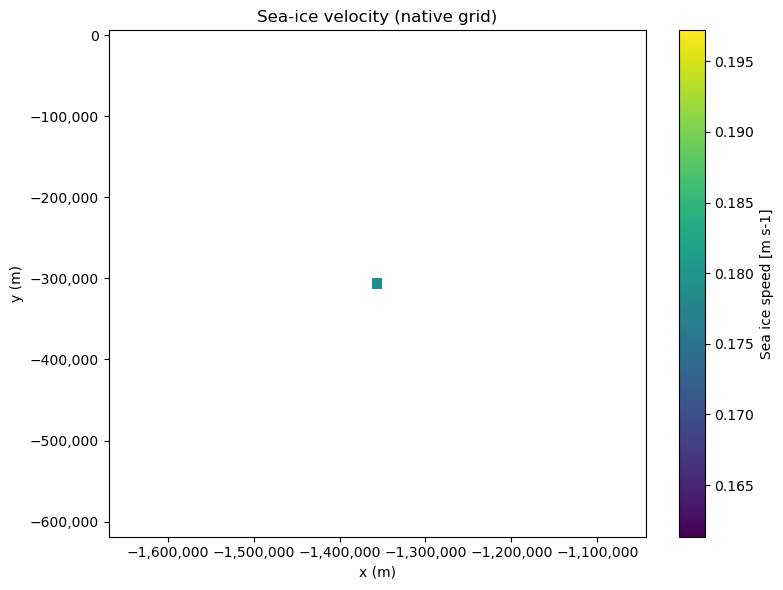

In [9]:
# let's see what the data looks like
# speed (m/day) on the native x/y grid

import matplotlib.ticker as mticker

speed = ds["sea_ice_speed"].isel(time=0)
valid_mask = np.isfinite(speed.values)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(ds['x'], ds['y'], speed, shading='auto')

plt.colorbar(
    im,
    ax=ax,
    label=f"{speed.attrs.get('long_name', 'Speed')} [{speed.attrs.get('units', '')}]"
)

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Sea-ice velocity (native grid)')


if np.any(valid_mask):
    y_idx, x_idx = np.where(valid_mask)
    x_vals = ds['x'].values
    y_vals = ds['y'].values
    
    x_min = x_vals[x_idx.min()]
    x_max = x_vals[x_idx.max()]
    y_min = y_vals[y_idx.min()]
    y_max = y_vals[y_idx.max()]
    
    # pad by grid spacing so the data does not touch plot edges
    dx = float(np.abs(x_vals[1] - x_vals[0])) if len(x_vals) > 1 else 0.0
    dy = float(np.abs(y_vals[1] - y_vals[0])) if len(y_vals) > 1 else 0.0

    pad_x = 25 * dx
    pad_y = 25 * dy

    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)

# turn off scientific notation / offset on both axes
ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
             
plt.tight_layout()
plt.show()

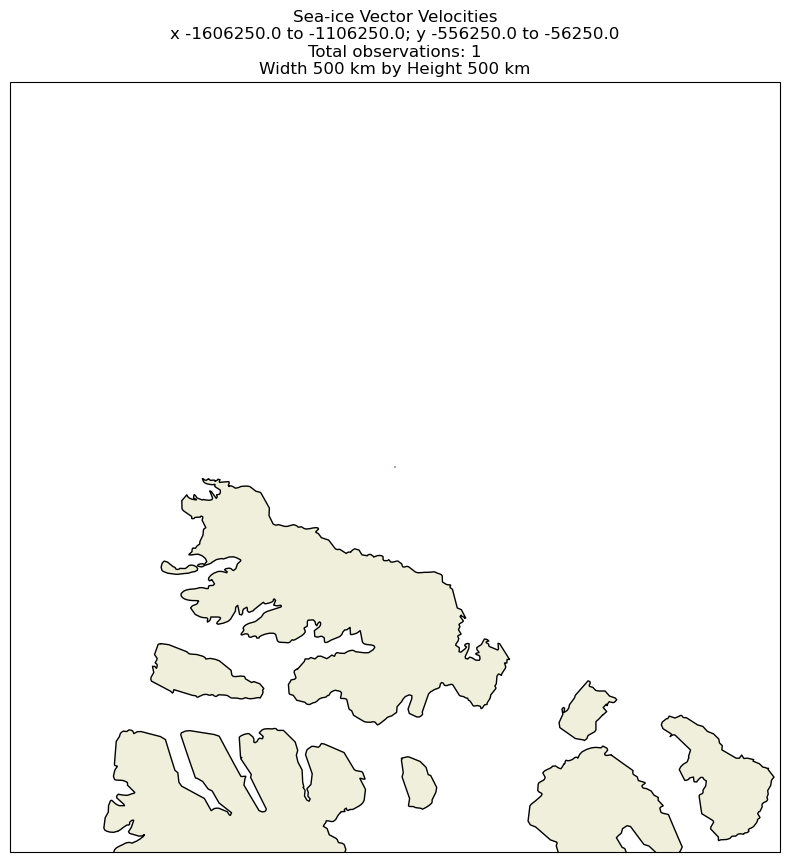

In [10]:
# plot vectors by using quivers for one scene

x_values = ds['x'].values
y_values = ds['y'].values
dx_values = ds["sea_ice_x_displacement"].isel(time=0).values
dy_values = ds["sea_ice_y_displacement"].isel(time=0).values
mag = np.hypot(dx_values, dy_values) # values in m

# determine total valid observations
arr = ds['sea_ice_speed'].isel(time=0).values
valid = np.isfinite(arr) # ignore any NaN values

# set projection defined by data set
globe_3411 = ccrs.Globe(semimajor_axis=6378273.0, semiminor_axis=6356889.449)

crs_3411 = ccrs.Stereographic(
    central_latitude=90,
    central_longitude=-45,
    false_easting=0.0,
    false_northing=0.0,
    true_scale_latitude=70,
    globe=globe_3411
)
    
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=crs_3411)

# Set extent in the projection's coordinate system (meters)
y_idx, x_idx = np.where(valid)
pad = 250_000 # 50km <-- change the pad to change scope of view
xmin = np.round(x_values[x_idx.min()] - pad, 3)
xmax = np.round(x_values[x_idx.max()] + pad, 3)
ymin = np.round(y_values[y_idx.min()] - pad, 3)
ymax = np.round(y_values[y_idx.max()] + pad, 3)

# set reasonable size of quivers based on dataset extent
map_width = xmax - xmin
map_height = ymax - ymin
map_span = np.round(max(map_height, map_width), 0)
if map_span > 2_000_000:
    quiver_scale = 0.1
else:
    quiver_scale = 1.0
ax.set_extent([xmin, xmax, ymin, ymax], crs=crs_3411)

# Coastlines / land
ax.add_feature(cfeature.LAND, zorder=0)
ax.coastlines(resolution="10m", linewidth=1.0, zorder=1)

ax.quiver(
    x_values, y_values, dx_values, dy_values, mag,
    transform=crs_3411,
    angles="xy", scale_units="xy",
    scale=quiver_scale,
    width=0.002, pivot="tail",
    color="green", zorder=2
)


ax.set_title(
    f"Sea-ice Vector Velocities\n"
    f"x {xmin} to {xmax}; y {ymin} to {ymax}\n"
    f"Total observations: {valid.sum()}\n"
    f"Width {np.int32(map_height / 1000)} km by Height {np.int32(map_width / 1000)} km"
)

plt.show() 

In [11]:
# Subsetting by time and x/y

# Select by time (works even if there is only one time)
da_speed = ds["sea_ice_speed"].sel(time=ds.time.values[0])
print(da_speed)

# subset of data set near center of grid extended by 50 km
xmid = float(ds.x.mean())
ymid = float(ds.y.mean())

subset = ds.sel(
    x=slice(xmid - 50_000, xmid + 50_000),
    y=slice(ymid - 50_000, ymid + 50_000),
)

subset

<xarray.DataArray 'sea_ice_speed' (y: 896, x: 608)> Size: 2MB
[544768 values with dtype=float32]
Coordinates:
  * x        (x) float64 5kB -3.844e+06 -3.831e+06 ... 3.731e+06 3.744e+06
  * y        (y) float64 7kB 5.844e+06 5.831e+06 ... -5.331e+06 -5.344e+06
    time     float64 8B 7.822e+08
Attributes:
    _FillValue:     nan
    long_name:      Sea ice speed
    standard_name:  sea_ice_speed
    ioos_category:  sea-ice
    units:          m s-1
    grid_mapping:   spatial_ref


<xarray.Dataset> Size: 3kB
Dimensions:                            (time: 127, y: 0, x: 8, nv: 2)
Coordinates:
  * nv                                 (nv) int64 16B 0 1
  * x                                  (x) float64 64B -9.375e+04 ... -6.25e+03
  * y                                  (y) float64 0B 
  * time                               (time) float64 1kB 7.822e+08 ... 7.823...
Data variables:
    sea_ice_speed                      (time, y, x) float32 0B ...
    sea_ice_x_displacement             (time, y, x) float32 0B ...
    sea_ice_y_displacement             (time, y, x) float32 0B ...
    direction_of_sea_ice_displacement  (time, y, x) float32 0B ...
    outlier_category                   (time, y, x) int16 0B ...
    bearing_error                      (time, y, x) int16 0B ...
    speed_error                        (time, y, x) int16 0B ...
    measurement_error                  (time, y, x) int16 0B ...
    spatial_ref                        int32 4B ...
    time_bnds                          (time, nv) float64 2kB ...
Attributes: (12/38)
    Conventions:               CF-1.8, ACDD-1.3
    title:                     Daily Northern Hemisphere SAR sea-ice velocity...
    summary:                   NetCDF version of the SAR Daily Drift dataset....
    acknowledgement:           Produced by NOAA using IABP data.
    creator_name:              Brendon Gory
    creator_email:             brendon.gory@noaa.gov
    ...                        ...
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    date_created:              2026-03-17T20:55:16Z
    time_coverage_start:       2024-10-14T01:02:01Z
    time_coverage_end:         2024-10-15T23:59:59Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D

In [12]:
# Export to NumPy arrays (for use in other Python tools)

# Pull arrays into memory (NumPy)
# shape (time, y, x)
time_bnds_all_values = ds["time_bnds"].values
speed_all_values = ds["sea_ice_speed"].values        
dx_all_values = ds["sea_ice_x_displacement"].values
dy_all_values = ds["sea_ice_y_displacement"].values
bear_all_values = ds["direction_of_sea_ice_displacement"].values
outlier_category_all_values = ds["outlier_category"].values
bearing_error_all_values = ds["bearing_error"].values
speed_error_all_values = ds["speed_error"].values
measurement_error_all_values = ds["measurement_error"].values

# dimensions
x_all_values = ds["x"].values
y_all_values = ds["y"].values
t_all_values = ds["time"].values

# note these are all values, not just valid observations
print("speed_all_values:", speed_all_values.shape, speed_all_values.dtype)

# Save a compact bundle (recommended)
os.makedirs('npz', exist_ok=True)
out_npz = r"npz/SIVelocity_export_arrays.npz"
np.savez_compressed(
    out_npz,
    sea_ice_speed=speed_all_values,
    sea_ice_x_displacement=dx_all_values,
    sea_ice_y_displacement=dy_all_values,
    direction_of_sea_ice_displacement=bear_all_values,
    outlier_category=outlier_category_all_values,
    bearing_error=bearing_error_all_values,
    speed_error=speed_error_all_values,
    measurement_error=measurement_error_all_values,
    time_bnds=time_bnds_all_values,
    x=x_all_values,
    y=y_all_values,
    time=t_all_values,
)

print("Wrote:", out_npz)

speed_all_values: (127, 896, 608) float32
Wrote: npz/SIVelocity_export_arrays.npz


In [13]:
# view the saved compressed NumPy file in a Pandas data frame
with np.load(r"npz/SIVelocity_export_arrays.npz", allow_pickle=True) as npz:
    sea_ice_speed = npz["sea_ice_speed"]
    sea_ice_x_displacement = npz["sea_ice_x_displacement"]
    sea_ice_y_displacement = npz["sea_ice_y_displacement"]
    direction_of_sea_ice_displacement = npz["direction_of_sea_ice_displacement"]
    outlier_category = npz["outlier_category"]
    bearing_error = npz["bearing_error"]
    speed_error = npz["speed_error"]
    measurement_error = npz["measurement_error"]
    time_bnds = npz["time_bnds"]
    x = npz["x"]
    y = npz["y"]
    t = npz["time"]


# build coordinates for each time
all_times, all_ys, all_xs = np.meshgrid(t, y, x, indexing='ij') # indexing allows meshgrid axes to match original data set

num_rows = len(y) * len(x)
time_start = np.repeat(time_bnds[:, 0], num_rows)
time_end = np.repeat(time_bnds[:, 1], num_rows)

df = pd.DataFrame({
    "time": all_times.ravel(),
    "time_start": time_start,
    "time_end": time_end,
    "y": all_ys.ravel(),
    "x": all_xs.ravel(),
    "sea_ice_speed": sea_ice_speed.ravel(),
    "sea_ice_x_displacement": sea_ice_x_displacement.ravel(),
    "sea_ice_y_displacement": sea_ice_y_displacement.ravel(),
    "direction_of_sea_ice_displacement": direction_of_sea_ice_displacement.ravel(),
    "outlier_category": outlier_category.ravel(),
    "bearing_error": bearing_error.ravel(),
    "speed_error": speed_error.ravel(),
    "measurement_error": measurement_error.ravel()
})

print(f"Full table details:\n{df.shape}")
display(df.head())
display(df.tail())

# If only keeping valid speed observations
df = df[np.isfinite(df["sea_ice_speed"])].reset_index(drop=True)
print(f"Only valid values table:\n{df.shape}")
display(df.head())
display(df.tail())

Full table details:
(69185536, 13)


,time,time_start,time_end,y,x,sea_ice_speed,sea_ice_x_displacement,sea_ice_y_displacement,direction_of_sea_ice_displacement,outlier_category,bearing_error,speed_error,measurement_error
0,782182921.0,782182921.0,782269789.0,5843750.0,-3843750.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9
1,782182921.0,782182921.0,782269789.0,5843750.0,-3831250.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9
2,782182921.0,782182921.0,782269789.0,5843750.0,-3818750.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9
3,782182921.0,782182921.0,782269789.0,5843750.0,-3806250.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9
4,782182921.0,782182921.0,782269789.0,5843750.0,-3793750.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9


,time,time_start,time_end,y,x,sea_ice_speed,sea_ice_x_displacement,sea_ice_y_displacement,direction_of_sea_ice_displacement,outlier_category,bearing_error,speed_error,measurement_error
69185531,782264397.0,782264397.0,782348661.0,-5343750.0,3693750.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9
69185532,782264397.0,782264397.0,782348661.0,-5343750.0,3706250.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9
69185533,782264397.0,782264397.0,782348661.0,-5343750.0,3718750.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9
69185534,782264397.0,782264397.0,782348661.0,-5343750.0,3731250.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9
69185535,782264397.0,782264397.0,782348661.0,-5343750.0,3743750.0,NaN,NaN,NaN,NaN,-9,-9,-9,-9


Only valid values table:
(7132, 13)


,time,time_start,time_end,y,x,sea_ice_speed,sea_ice_x_displacement,sea_ice_y_displacement,direction_of_sea_ice_displacement,outlier_category,bearing_error,speed_error,measurement_error
0,782182921.0,782182921.0,782269789.0,-306250.0,-1356250.0,0.179270,-0.17878,0.01321,274.225372,0,0,0,1
1,782184835.0,782184835.0,782271702.0,-18750.0,-1443750.0,0.226338,-0.16875,-0.15084,228.207703,0,0,0,1
2,782184835.0,782184835.0,782271702.0,-31250.0,-1456250.0,0.002260,0.00000,0.00000,0.000000,40,1,0,0
3,782184835.0,782184835.0,782271702.0,-31250.0,-1443750.0,0.224032,-0.16789,-0.14833,228.539520,0,0,0,0
4,782184835.0,782184835.0,782271702.0,-43750.0,-1456250.0,0.214782,-0.16933,-0.13213,232.033707,0,0,0,0


,time,time_start,time_end,y,x,sea_ice_speed,sea_ice_x_displacement,sea_ice_y_displacement,direction_of_sea_ice_displacement,outlier_category,bearing_error,speed_error,measurement_error
7127,782263991.0,782263991.0,782348661.0,1081250.0,456250.0,0.098914,-0.07214,-0.06768,226.825653,0,0,0,0
7128,782263991.0,782263991.0,782348661.0,1043750.0,431250.0,0.098171,-0.07254,-0.06615,227.636276,0,0,0,0
7129,782264397.0,782264397.0,782348661.0,1181250.0,506250.0,0.177915,-0.12882,-0.12272,226.389664,40,0,0,0
7130,782264397.0,782264397.0,782348661.0,1168750.0,493750.0,0.180095,-0.12421,-0.13041,223.605606,20,0,0,1
7131,782264397.0,782264397.0,782348661.0,1168750.0,506250.0,0.180781,-0.12510,-0.13050,223.790039,0,0,0,0


In [14]:
# always close dataset
# accessing file from other locations or rerunning code can result in file locks or access conflicts
ds.close()